# Multi-Dataset Evaluation: RUL Prediction Across All C-MAPSS Sub-Datasets (FD001 → FD004)

This notebook evaluates **3 models** (Random Forest, LSTM, Bi-LSTM) across all **4 C-MAPSS sub-datasets** independently to understand how model performance varies with dataset complexity.

| Dataset | Operating Conditions | Fault Modes | Difficulty |
|---------|---------------------|-------------|------------|
| FD001   | 1 (Sea Level)       | 1 (HPC)     | Easiest    |
| FD002   | 6                   | 1 (HPC)     | Hard       |
| FD003   | 1 (Sea Level)       | 2 (HPC+Fan) | Medium     |
| FD004   | 6                   | 2 (HPC+Fan) | Hardest    |

**Models Evaluated:**
1. **Random Forest Regressor** — Classical baseline with clipped RUL training
2. **LSTM** — Two-layer LSTM (100→50 units) with dropout
3. **Bi-LSTM** — Bidirectional LSTM (100→50 units) with dropout

**Metrics:** RMSE, R², NASA Asymmetric S-Score

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd

# Set TensorFlow env flags before importing TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Import TensorFlow first to avoid occasional DLL/backend issues on Windows
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded. TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

E0000 00:00:1776921159.719541    3196 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776921159.728128    3196 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776921159.749142    3196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776921159.749178    3196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776921159.749181    3196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776921159.749184    3196 computation_placer.cc:177] computation placer already registered. Please check linka

Libraries loaded. TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Configuration
DATASETS = ["FD001", "FD002", "FD003", "FD004"]
RUL_CLIP_VALUE = 125
SEQUENCE_LENGTH = 50
EPOCHS = 80
BATCH_SIZE = 128

IS_KAGGLE = os.path.exists("/kaggle/input")
KAGGLE_DATASET_NAME = "RUL_Project_Dataset"

def _looks_like_cmapss_dataset(path):
    required = [
        "train_FD001.txt", "train_FD002.txt", "train_FD003.txt", "train_FD004.txt",
        "test_FD001.txt", "test_FD002.txt", "test_FD003.txt", "test_FD004.txt",
        "RUL_FD001.txt", "RUL_FD002.txt", "RUL_FD003.txt", "RUL_FD004.txt",
    ]
    return all(os.path.isfile(os.path.join(path, name)) for name in required)

if IS_KAGGLE:
    input_root = "/kaggle/input"
    search_roots = []

    preferred = os.path.join(input_root, KAGGLE_DATASET_NAME)
    if os.path.isdir(preferred):
        search_roots.append(preferred)

    datasets_root = os.path.join(input_root, "datasets")
    if os.path.isdir(datasets_root):
        search_roots.append(datasets_root)

    search_roots.append(input_root)

    found_data_dir = None
    for root in search_roots:
        for cur, dirs, _ in os.walk(root):
            if os.path.basename(cur) == "DATASET" and _looks_like_cmapss_dataset(cur):
                found_data_dir = cur
                break
        if found_data_dir:
            break

    if not found_data_dir:
        raise FileNotFoundError(
            "Could not find a valid C-MAPSS DATASET directory under /kaggle/input. "
            f"Top-level entries: {os.listdir(input_root)}"
        )

    DATA_DIR = found_data_dir
    RESULTS_DIR = "/kaggle/working/results"
else:
    DATA_DIR = "C-MPASS/DATASET"
    RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Running on Kaggle: {IS_KAGGLE}")
if IS_KAGGLE:
    print(f"Available /kaggle/input dirs: {os.listdir('/kaggle/input')}")
print(f"Data directory: {DATA_DIR}")
print(f"Datasets to evaluate: {DATASETS}")
print(f"Results will be saved to: {RESULTS_DIR}/")

Running on Kaggle: True
Available /kaggle/input dirs: ['datasets']
Data directory: /kaggle/input/datasets/saisrisatvic/rul-project-datset/C-MPASS/DATASET
Datasets to evaluate: ['FD001', 'FD002', 'FD003', 'FD004']
Results will be saved to: /kaggle/working/results/


## 2. Data Loading

Load train, test, and ground-truth RUL files for a given sub-dataset.
The raw data is space-separated with no header row and 26 columns.

In [3]:
# Column names for the C-MAPSS dataset
COLUMN_NAMES = (
    ['engine_id', 'time_in_cycles'] +
    [f'setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

def load_dataset(dataset_name):
    """
    Load train, test, and RUL ground truth for a single C-MAPSS sub-dataset.
    
    Args:
        dataset_name: One of 'FD001', 'FD002', 'FD003', 'FD004'
    
    Returns:
        train_df, test_df, truth_df
    """
    train_path = os.path.join(DATA_DIR, f"train_{dataset_name}.txt")
    test_path = os.path.join(DATA_DIR, f"test_{dataset_name}.txt")
    rul_path = os.path.join(DATA_DIR, f"RUL_{dataset_name}.txt")
    
    # Load data - space separated, no header
    train_df = pd.read_csv(train_path, sep=r'\s+', header=None)
    test_df = pd.read_csv(test_path, sep=r'\s+', header=None)
    truth_df = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])
    
    # Drop extra trailing columns (columns 26, 27 from trailing spaces)
    train_df.drop(columns=[26, 27], inplace=True, errors='ignore')
    test_df.drop(columns=[26, 27], inplace=True, errors='ignore')
    
    # Assign column names
    train_df.columns = COLUMN_NAMES
    test_df.columns = COLUMN_NAMES
    
    return train_df, test_df, truth_df

# Quick test
train_test, test_test, truth_test = load_dataset("FD001")
print(f"FD001 loaded: train={train_test.shape}, test={test_test.shape}, truth={truth_test.shape}")

FD001 loaded: train=(20631, 26), test=(13096, 26), truth=(100, 1)


## 3. Preprocessing & Feature Engineering

For each dataset independently:
1. **Drop constant-variance columns** (std == 0) — these carry no predictive signal
2. **Drop low-correlation columns** — sensor_1, sensor_5, sensor_10, sensor_16 (known to be uninformative)
3. **Add RUL column** to training data
4. **Clip RUL at 125 cycles** (piece-wise linear degradation model)
5. **MinMaxScaler** fit on train, transform both train and test

In [4]:
def preprocess_dataset(train_df, test_df, truth_df):
    """
    Full preprocessing pipeline for a single C-MAPSS sub-dataset.
    Uses the same logic as the working predictive-maintenance notebook.
    
    Returns:
        train_df, test_df, truth_df, feature_cols, scaler
    """
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # 1. Drop constant columns (zero standard deviation)
    stats = train_df.describe().transpose()
    constant_cols = stats[stats['std'] == 0].index.tolist()
    
    # 2. Also drop known low-correlation sensors
    low_corr_cols = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16']
    cols_to_drop = list(set(constant_cols + [c for c in low_corr_cols if c in train_df.columns]))
    
    train_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    test_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    print(f"  Dropped {len(cols_to_drop)} uninformative columns: {cols_to_drop}")
    
    # 3. Calculate RUL for training data
    max_cycles = train_df.groupby('engine_id')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycles']
    train_df = pd.merge(train_df, max_cycles, on='engine_id', how='left')
    train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
    train_df.drop(columns=['max_cycles'], inplace=True)
    
    # 4. Clip RUL at 125 cycles
    train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CLIP_VALUE)
    
    # 5. Identify feature columns
    feature_cols = train_df.columns.drop(['engine_id', 'time_in_cycles', 'RUL']).tolist()
    
    # 6. Scale features (fit on train, transform both)
    scaler = MinMaxScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])
    
    print(f"  Features after preprocessing: {len(feature_cols)}")
    print(f"  Train samples: {len(train_df)}, Test engines: {test_df['engine_id'].nunique()}")
    
    return train_df, test_df, truth_df, feature_cols, scaler

## 4. Sequence Builder for LSTM / Bi-LSTM

Creates sliding-window 3D sequences `(num_samples, sequence_length, num_features)` from the time-series data, with the target being the RUL at the end of each sequence.

For test data, we take only the **last sequence** per engine (with zero-padding if the engine has fewer cycles than the window).

In [5]:
def generate_train_sequences(train_df, seq_length, feature_cols):
    """
    Generate sliding window sequences from training data.
    Same logic as predictive-maintenance notebook.
    
    Returns:
        X_train (3D array), y_train (1D array)
    """
    sequences = []
    targets = []
    
    for engine_id in train_df['engine_id'].unique():
        engine_df = train_df[train_df['engine_id'] == engine_id]
        
        for i in range(len(engine_df) - seq_length + 1):
            seq = engine_df[feature_cols].iloc[i:i+seq_length].values
            target = engine_df['RUL'].iloc[i + seq_length - 1]
            sequences.append(seq)
            targets.append(target)
    
    return np.array(sequences), np.array(targets)


def generate_test_sequences(test_df, truth_df, seq_length, feature_cols):
    """
    Generate test sequences — last window per engine with zero-padding.
    Same logic as predictive-maintenance notebook.
    
    Returns:
        X_test (3D array), y_test (1D array)
    """
    X_test = []
    
    for engine_id in test_df['engine_id'].unique():
        engine_df = test_df[test_df['engine_id'] == engine_id]
        last_sequence = engine_df[feature_cols].tail(seq_length).values
        
        # Zero-pad if engine has fewer cycles than sequence_length
        if len(last_sequence) < seq_length:
            padded = np.zeros((seq_length, len(feature_cols)))
            padded[-len(last_sequence):] = last_sequence
            X_test.append(padded)
        else:
            X_test.append(last_sequence)
    
    X_test = np.array(X_test)
    y_test = truth_df['RUL'].values
    
    return X_test, y_test

## 5. Evaluation Metrics

Three metrics used for evaluation:
1. **RMSE** — Root Mean Squared Error (lower is better)
2. **R²** — R-Squared coefficient of determination (higher is better, max 1.0)
3. **NASA S-Score** — Asymmetric scoring function that penalizes overestimation (late predictions) more heavily than underestimation (early predictions). **Lower is better.**

In [7]:
def nasa_s_score(y_true, y_pred):
    """
    NASA C-MAPSS asymmetric scoring function.
    Overestimating RUL (predicting engine is safer than it is) is penalized 
    more heavily than underestimating.
    
    Same implementation as predictive-maintenance and bi-lstm notebooks.
    """
    d = y_pred.flatten() - y_true.flatten()
    score = 0
    for d_i in d:
        if d_i < 0:
            score += np.exp(-d_i / 13.0) - 1   # Early prediction (less dangerous)
        else:
            score += np.exp(d_i / 10.0) - 1     # Late prediction (more dangerous)
    return score


def evaluate_model(y_true, y_pred, model_name, dataset_name):
    """
    Compute all 3 metrics and return as a dictionary.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    s_score = nasa_s_score(y_true, y_pred)
    
    print(f"    {model_name} | RMSE: {rmse:.2f} | R²: {r2:.4f} | S-Score: {s_score:.2f}")
    
    return {
        'Dataset': dataset_name,
        'Model': model_name,
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4),
        'NASA S-Score': round(s_score, 2)
    }

## 6. Model Definitions

### 6.1 Random Forest Regressor
From `predictive-maintenance-on-nasa-turbofan-jet-engine.ipynb`:
- `n_estimators=100`, `max_depth=10`, `random_state=42`

In [8]:
def build_random_forest():
    """Build Random Forest with same hyperparameters as the working notebook."""
    return RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

### 6.2 LSTM Model
From `predictive-maintenance-on-nasa-turbofan-jet-engine.ipynb`:
- Layer 1: LSTM(100, return_sequences=True) + Dropout(0.2)
- Layer 2: LSTM(50) + Dropout(0.2)
- Output: Dense(1)
- Optimizer: Adam, Loss: MSE

In [9]:
def build_lstm(n_features):
    """Build LSTM with same architecture as the working notebook."""
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, n_features)),
        LSTM(units=100, return_sequences=True),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

### 6.3 Bidirectional LSTM Model
From `bi-lstm_rul.ipynb`:
- Layer 1: Bidirectional(LSTM(100, return_sequences=True)) + Dropout(0.2)
- Layer 2: Bidirectional(LSTM(50)) + Dropout(0.2)
- Dense(32, relu) + Dense(1)
- Optimizer: Adam, Loss: MSE

In [10]:
def build_bilstm(n_features):
    """Build Bi-LSTM with same architecture as the working notebook."""
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, n_features)),
        Bidirectional(LSTM(100, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(50)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

## 7. Main Evaluation Loop

For each of the 4 datasets:
1. Load and preprocess the data
2. Train and evaluate **Random Forest** (on last-cycle features)
3. Build sequences and train/evaluate **LSTM**
4. Build sequences and train/evaluate **Bi-LSTM**
5. Collect all metrics into a master results table

In [12]:
# Master results collector
all_results = []
all_predictions = {}  # Store predictions for scatter plots

In [13]:
for dataset_name in DATASETS:
    print(f"\n{'='*70}")
    print(f"  DATASET: {dataset_name}")
    print(f"{'='*70}")
    
    # Load Data
    train_df, test_df, truth_df = load_dataset(dataset_name)
    print(f"  Raw: train={train_df.shape}, test={test_df.shape}, truth={truth_df.shape}")
    
    # Preprocess
    train_df, test_df, truth_df, feature_cols, scaler = preprocess_dataset(
        train_df, test_df, truth_df
    )
    
    # MODEL 1: Random Forest
    print(f"\n  [1/3] Training Random Forest...")
    X_train_rf = train_df[feature_cols]
    y_train_rf = train_df['RUL']
    X_test_rf = test_df.groupby('engine_id').last()[feature_cols]
    y_test_rf = truth_df['RUL'].values
    
    rf_model = build_random_forest()
    rf_model.fit(X_train_rf, y_train_rf)
    y_pred_rf = rf_model.predict(X_test_rf)
    
    result_rf = evaluate_model(y_test_rf, y_pred_rf, "Random Forest", dataset_name)
    all_results.append(result_rf)
    all_predictions[(dataset_name, "Random Forest")] = (y_test_rf, y_pred_rf)
    
    # MODEL 2: LSTM
    print(f"  [2/3] Training LSTM...")
    X_train_seq, y_train_seq = generate_train_sequences(
        train_df, SEQUENCE_LENGTH, feature_cols
    )
    X_test_seq, y_test_seq = generate_test_sequences(
        test_df, truth_df, SEQUENCE_LENGTH, feature_cols
    )
    print(f"    Sequences: X_train={X_train_seq.shape}, X_test={X_test_seq.shape}")
    
    lstm_model = build_lstm(n_features=len(feature_cols))
    lstm_callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]
    lstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=lstm_callbacks,
        verbose=1
    )
    
    y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
    result_lstm = evaluate_model(y_test_seq, y_pred_lstm, "LSTM", dataset_name)
    all_results.append(result_lstm)
    all_predictions[(dataset_name, "LSTM")] = (y_test_seq, y_pred_lstm)
    
    # MODEL 3: Bi-LSTM
    print(f"  [3/3] Training Bi-LSTM...")
    bilstm_model = build_bilstm(n_features=len(feature_cols))
    bilstm_callbacks = [
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    ]
    bilstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=bilstm_callbacks,
        verbose=1
    )
    
    y_pred_bilstm = bilstm_model.predict(X_test_seq, verbose=0).flatten()
    result_bilstm = evaluate_model(y_test_seq, y_pred_bilstm, "Bi-LSTM", dataset_name)
    all_results.append(result_bilstm)
    all_predictions[(dataset_name, "Bi-LSTM")] = (y_test_seq, y_pred_bilstm)
    
    # Clear Keras session to free memory between datasets
    tf.keras.backend.clear_session()
    
    print(f"\n  {dataset_name} complete!")

print(f"\n{'='*70}")
print("  ALL DATASETS EVALUATED SUCCESSFULLY!")
print(f"{'='*70}")


  DATASET: FD001
  Raw: train=(20631, 26), test=(13096, 26), truth=(100, 1)
  Dropped 7 uninformative columns: ['sensor_5', 'sensor_1', 'sensor_18', 'sensor_10', 'sensor_19', 'sensor_16', 'setting_3']
  Features after preprocessing: 17
  Train samples: 20631, Test engines: 100

  [1/3] Training Random Forest...
    Random Forest | RMSE: 18.10 | R²: 0.8102 | S-Score: 924.41
  [2/3] Training LSTM...
    Sequences: X_train=(15731, 50, 17), X_test=(100, 50, 17)


I0000 00:00:1776921257.747467    3196 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/80


I0000 00:00:1776921261.686486    3281 cuda_dnn.cc:529] Loaded cuDNN version 91002


99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 6216.0503 - val_loss: 6106.8350 - learning_rate: 0.0010
Epoch 2/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5085.6748 - val_loss: 5457.5117 - learning_rate: 0.0010
Epoch 3/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4522.4189 - val_loss: 4903.9204 - learning_rate: 0.0010
Epoch 4/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4054.7363 - val_loss: 4423.6636 - learning_rate: 0.0010
Epoch 5/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3646.5054 - val_loss: 4006.2554 - learning_rate: 0.0010
Epoch 6/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3289.4993 - val_loss: 3644.9783 - learning_rate: 0.0010
Epoch 7/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3001.0500 - val_loss: 3333.7915 - learning_rate: 0.0010
Epoch 8/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2753.2205 - val_loss: 3067.2754 - learning_rate: 0.0010
Epoch 9/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2539.2563 - val_loss: 2840.1130 

## 8. Results — Unified Comparison Table

In [14]:
# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Display styled table
print("\n" + "="*70)
print("  MULTI-DATASET EVALUATION RESULTS")
print("="*70)
print()
print(results_df.to_string(index=False))

# Save to CSV
csv_path = os.path.join(RESULTS_DIR, "multi_dataset_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"\n✓ Results saved to {csv_path}")


  MULTI-DATASET EVALUATION RESULTS

Dataset         Model  RMSE      R²  NASA S-Score
  FD001 Random Forest 18.10  0.8102        924.41
  FD001          LSTM 14.98  0.8700        378.29
  FD001       Bi-LSTM 15.56  0.8598        389.29
  FD002 Random Forest 30.48  0.6788      12660.21
  FD002          LSTM 54.17 -0.0147     133556.91
  FD002       Bi-LSTM 33.57  0.6104      24115.26
  FD003 Random Forest 21.22  0.7372       1819.00
  FD003          LSTM 42.51 -0.0544      26325.87
  FD003       Bi-LSTM 15.42  0.8613        651.74
  FD004 Random Forest 32.08  0.6539      11595.93
  FD004          LSTM 54.56 -0.0013     119996.84
  FD004       Bi-LSTM 33.99  0.6113      14893.08

✓ Results saved to /kaggle/working/results/multi_dataset_results.csv


In [15]:
# Pivot table for easier comparison
print("\n─── RMSE Comparison (lower is better) ───")
rmse_pivot = results_df.pivot(index='Dataset', columns='Model', values='RMSE')
rmse_pivot = rmse_pivot[['Random Forest', 'LSTM', 'Bi-LSTM']]  # Order columns
print(rmse_pivot.to_string())

print("\n─── R² Comparison (higher is better) ───")
r2_pivot = results_df.pivot(index='Dataset', columns='Model', values='R²')
r2_pivot = r2_pivot[['Random Forest', 'LSTM', 'Bi-LSTM']]
print(r2_pivot.to_string())

print("\n─── NASA S-Score Comparison (lower is better) ───")
sscore_pivot = results_df.pivot(index='Dataset', columns='Model', values='NASA S-Score')
sscore_pivot = sscore_pivot[['Random Forest', 'LSTM', 'Bi-LSTM']]
print(sscore_pivot.to_string())


─── RMSE Comparison (lower is better) ───
Model    Random Forest   LSTM  Bi-LSTM
Dataset                               
FD001            18.10  14.98    15.56
FD002            30.48  54.17    33.57
FD003            21.22  42.51    15.42
FD004            32.08  54.56    33.99

─── R² Comparison (higher is better) ───
Model    Random Forest    LSTM  Bi-LSTM
Dataset                                
FD001           0.8102  0.8700   0.8598
FD002           0.6788 -0.0147   0.6104
FD003           0.7372 -0.0544   0.8613
FD004           0.6539 -0.0013   0.6113

─── NASA S-Score Comparison (lower is better) ───
Model    Random Forest       LSTM   Bi-LSTM
Dataset                                    
FD001           924.41     378.29    389.29
FD002         12660.21  133556.91  24115.26
FD003          1819.00   26325.87    651.74
FD004         11595.93  119996.84  14893.08


## 9. Visualizations

### 9.1 RMSE Comparison Bar Chart

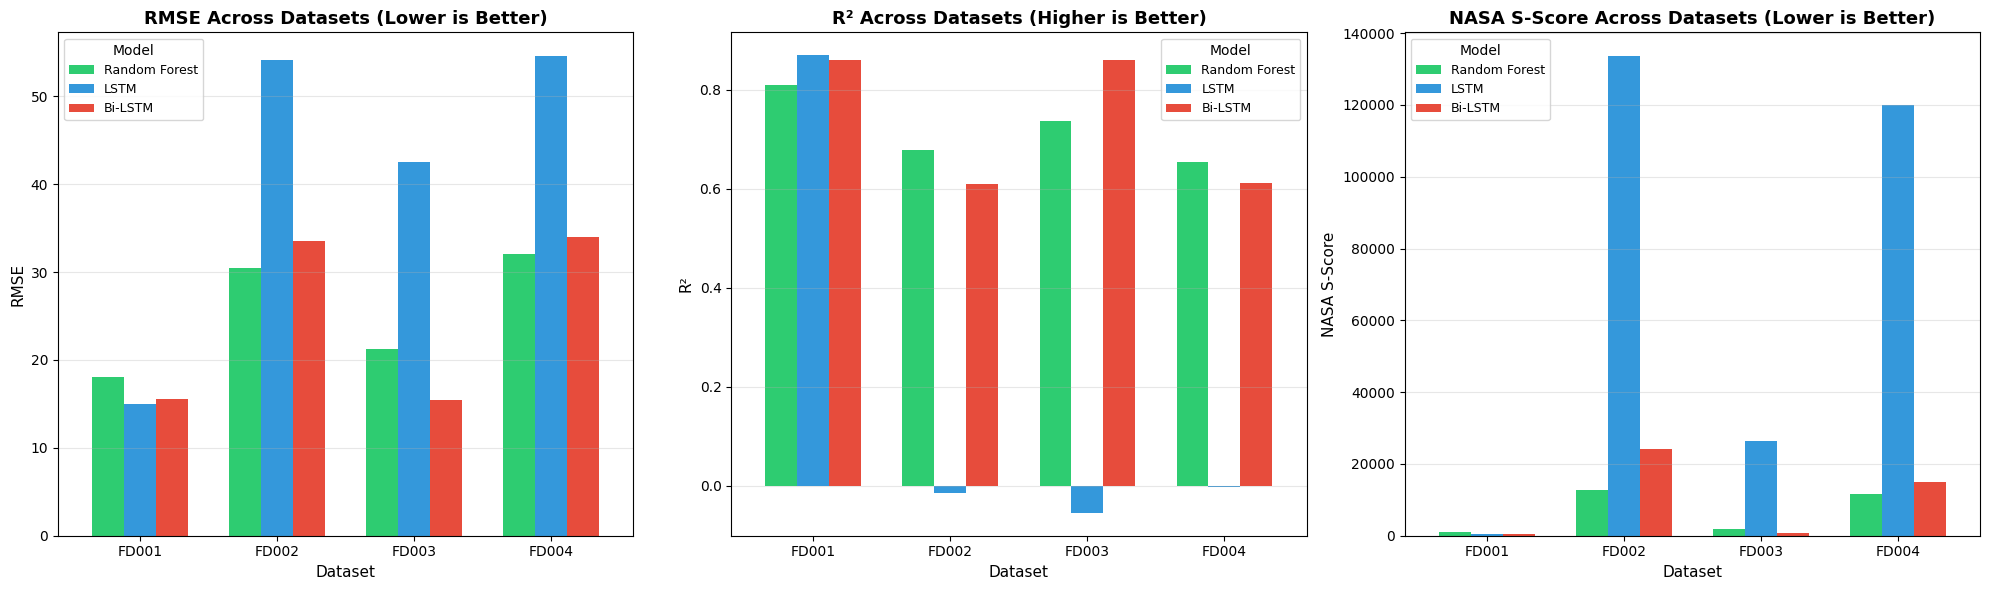

✓ Summary chart saved to /kaggle/working/results/summary_comparison.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['RMSE', 'R²', 'NASA S-Score']
titles = [
    'RMSE Across Datasets (Lower is Better)',
    'R² Across Datasets (Higher is Better)', 
    'NASA S-Score Across Datasets (Lower is Better)'
]

for ax, metric, title in zip(axes, metrics, titles):
    pivot = results_df.pivot(index='Dataset', columns='Model', values=metric)
    pivot = pivot[['Random Forest', 'LSTM', 'Bi-LSTM']]
    
    pivot.plot(kind='bar', ax=ax, rot=0, width=0.7,
               color=['#2ecc71', '#3498db', '#e74c3c'])
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.legend(title='Model', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Summary chart saved to {RESULTS_DIR}/summary_comparison.png")

### 9.2 Predicted vs True RUL — Scatter Plots

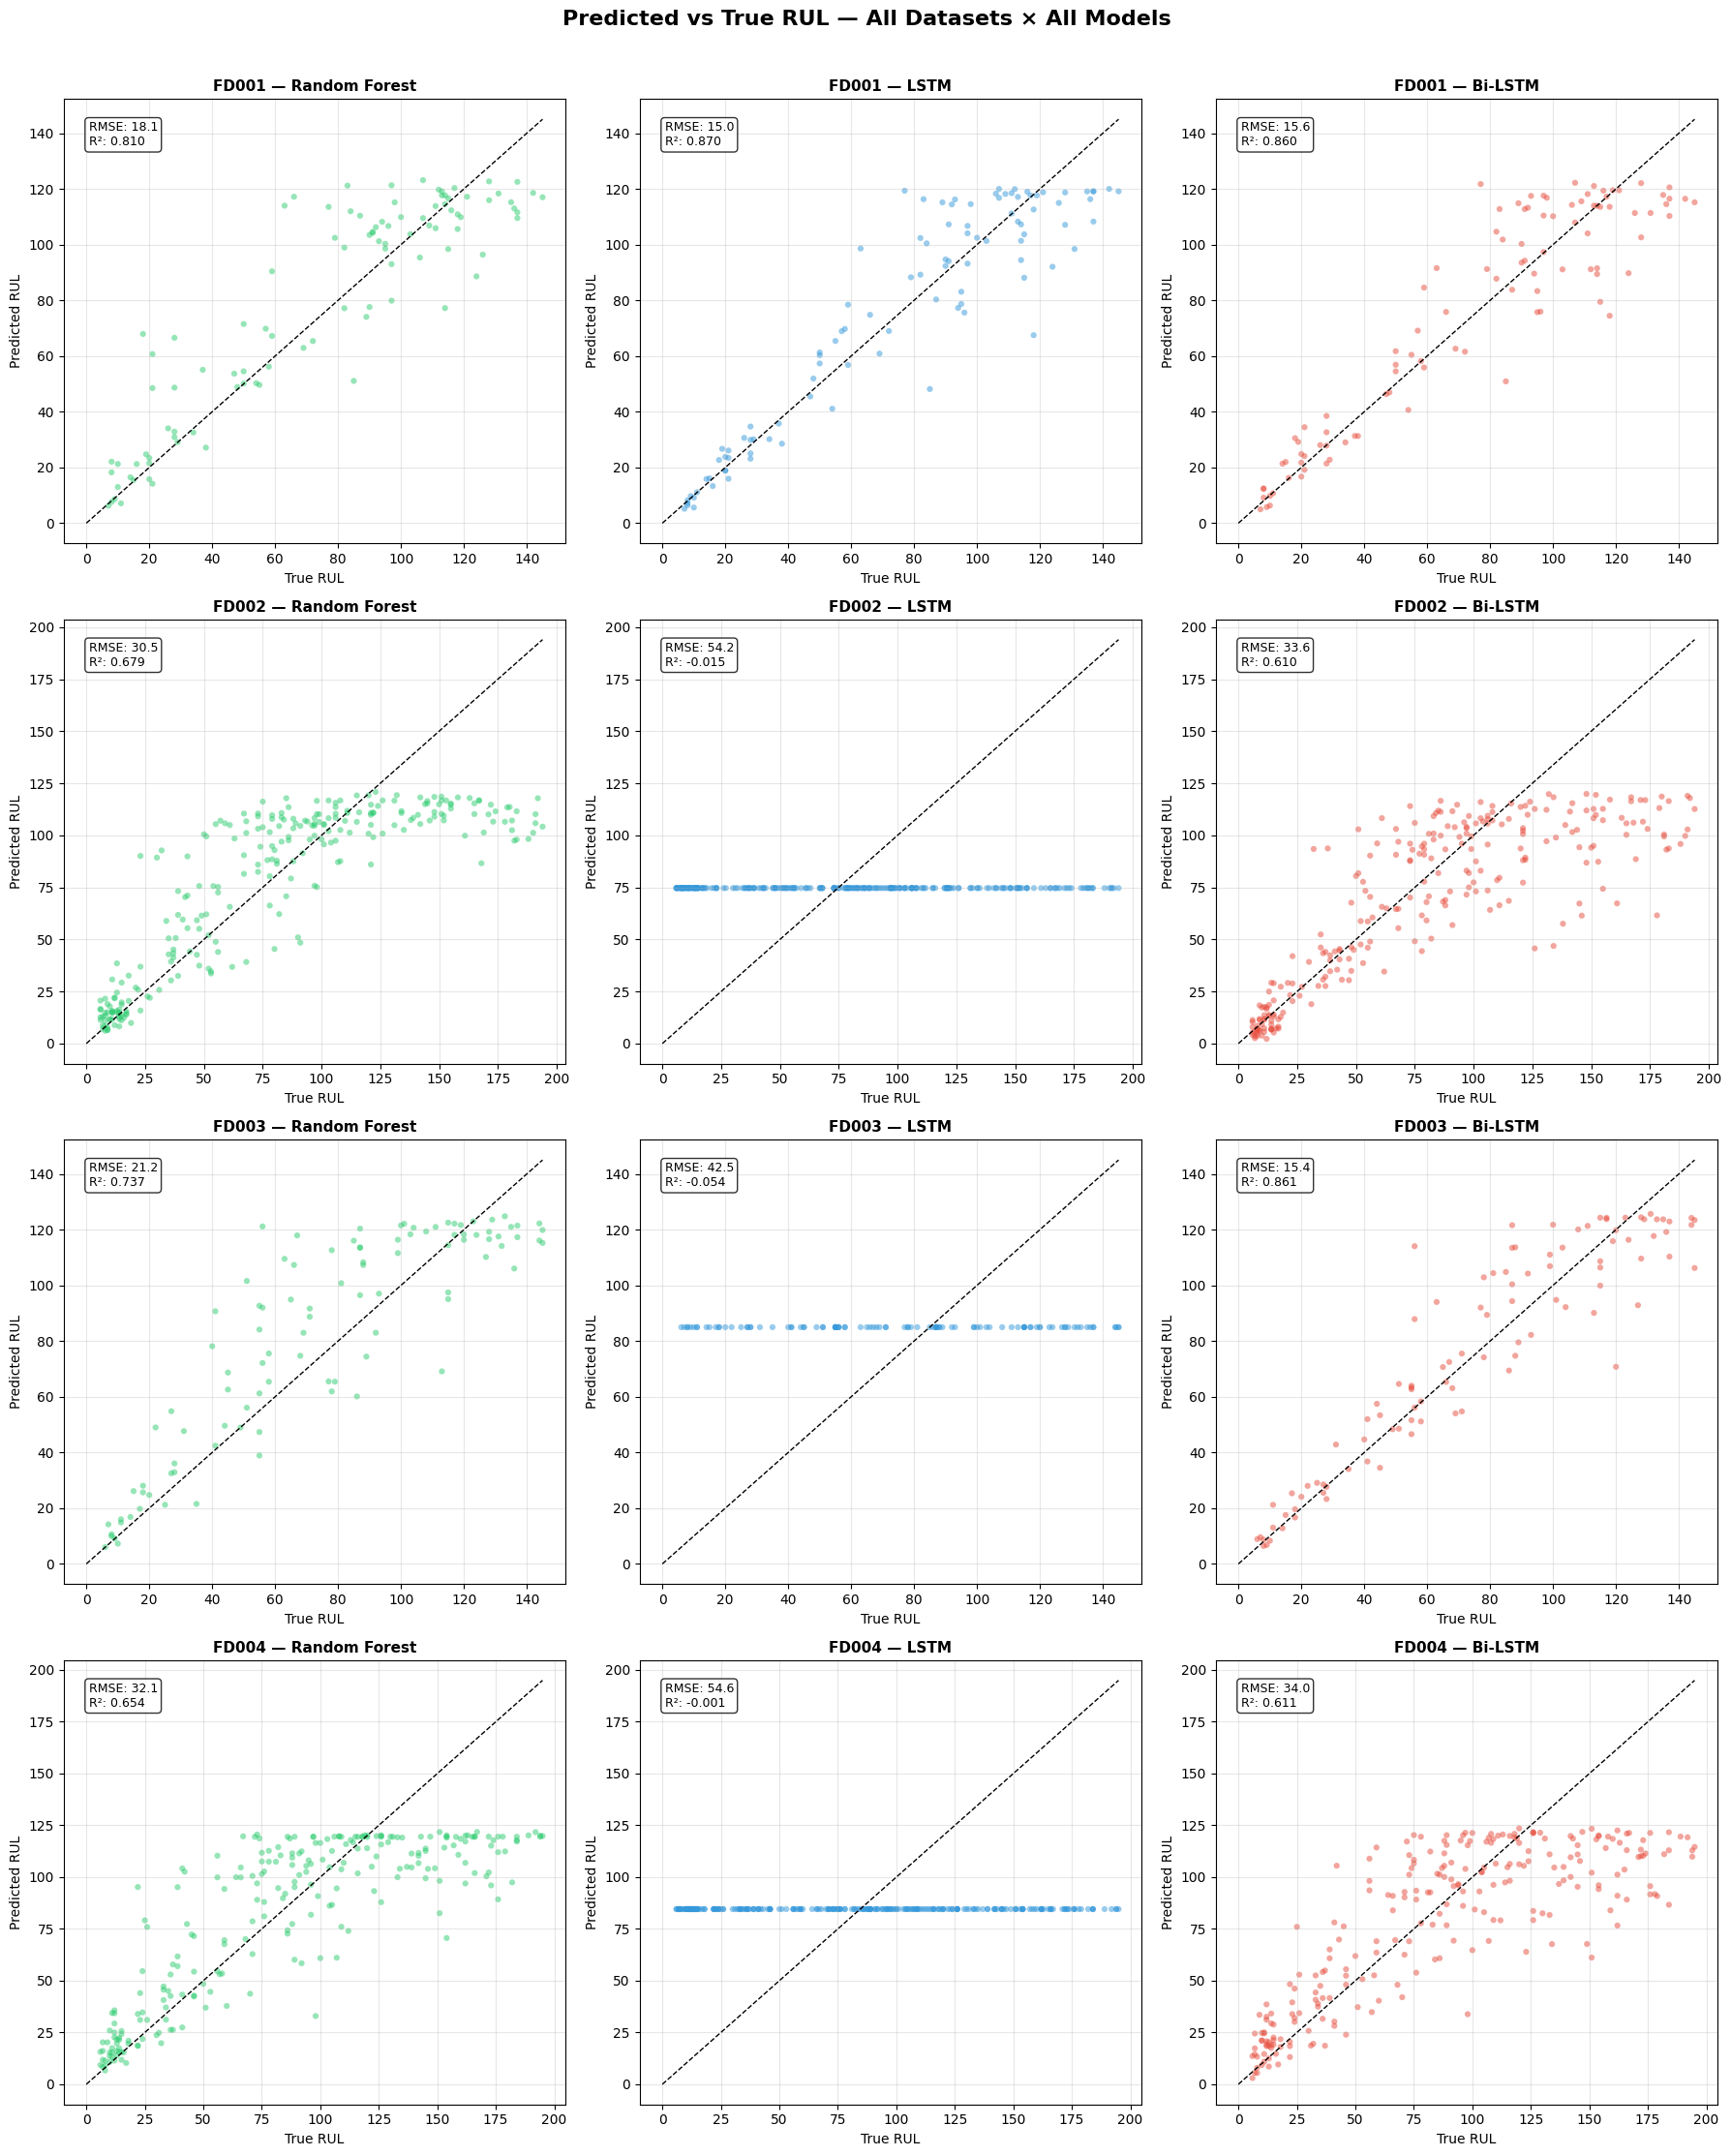

✓ Scatter plots saved to /kaggle/working/results/scatter_all.png


In [17]:
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

model_names = ['Random Forest', 'LSTM', 'Bi-LSTM']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for row, dataset_name in enumerate(DATASETS):
    for col, (model_name, color) in enumerate(zip(model_names, colors)):
        ax = axes[row, col]
        
        y_true, y_pred = all_predictions[(dataset_name, model_name)]
        
        # Scatter plot
        ax.scatter(y_true, y_pred, alpha=0.5, s=20, color=color, edgecolors='none')
        
        # Perfect prediction line
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect')
        
        # Metrics annotation
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        ax.text(0.05, 0.95, f'RMSE: {rmse:.1f}\nR²: {r2:.3f}', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_title(f'{dataset_name} — {model_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('True RUL')
        ax.set_ylabel('Predicted RUL')
        ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs True RUL — All Datasets × All Models', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "scatter_all.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Scatter plots saved to {RESULTS_DIR}/scatter_all.png")

### 9.3 Error Distribution — Histograms

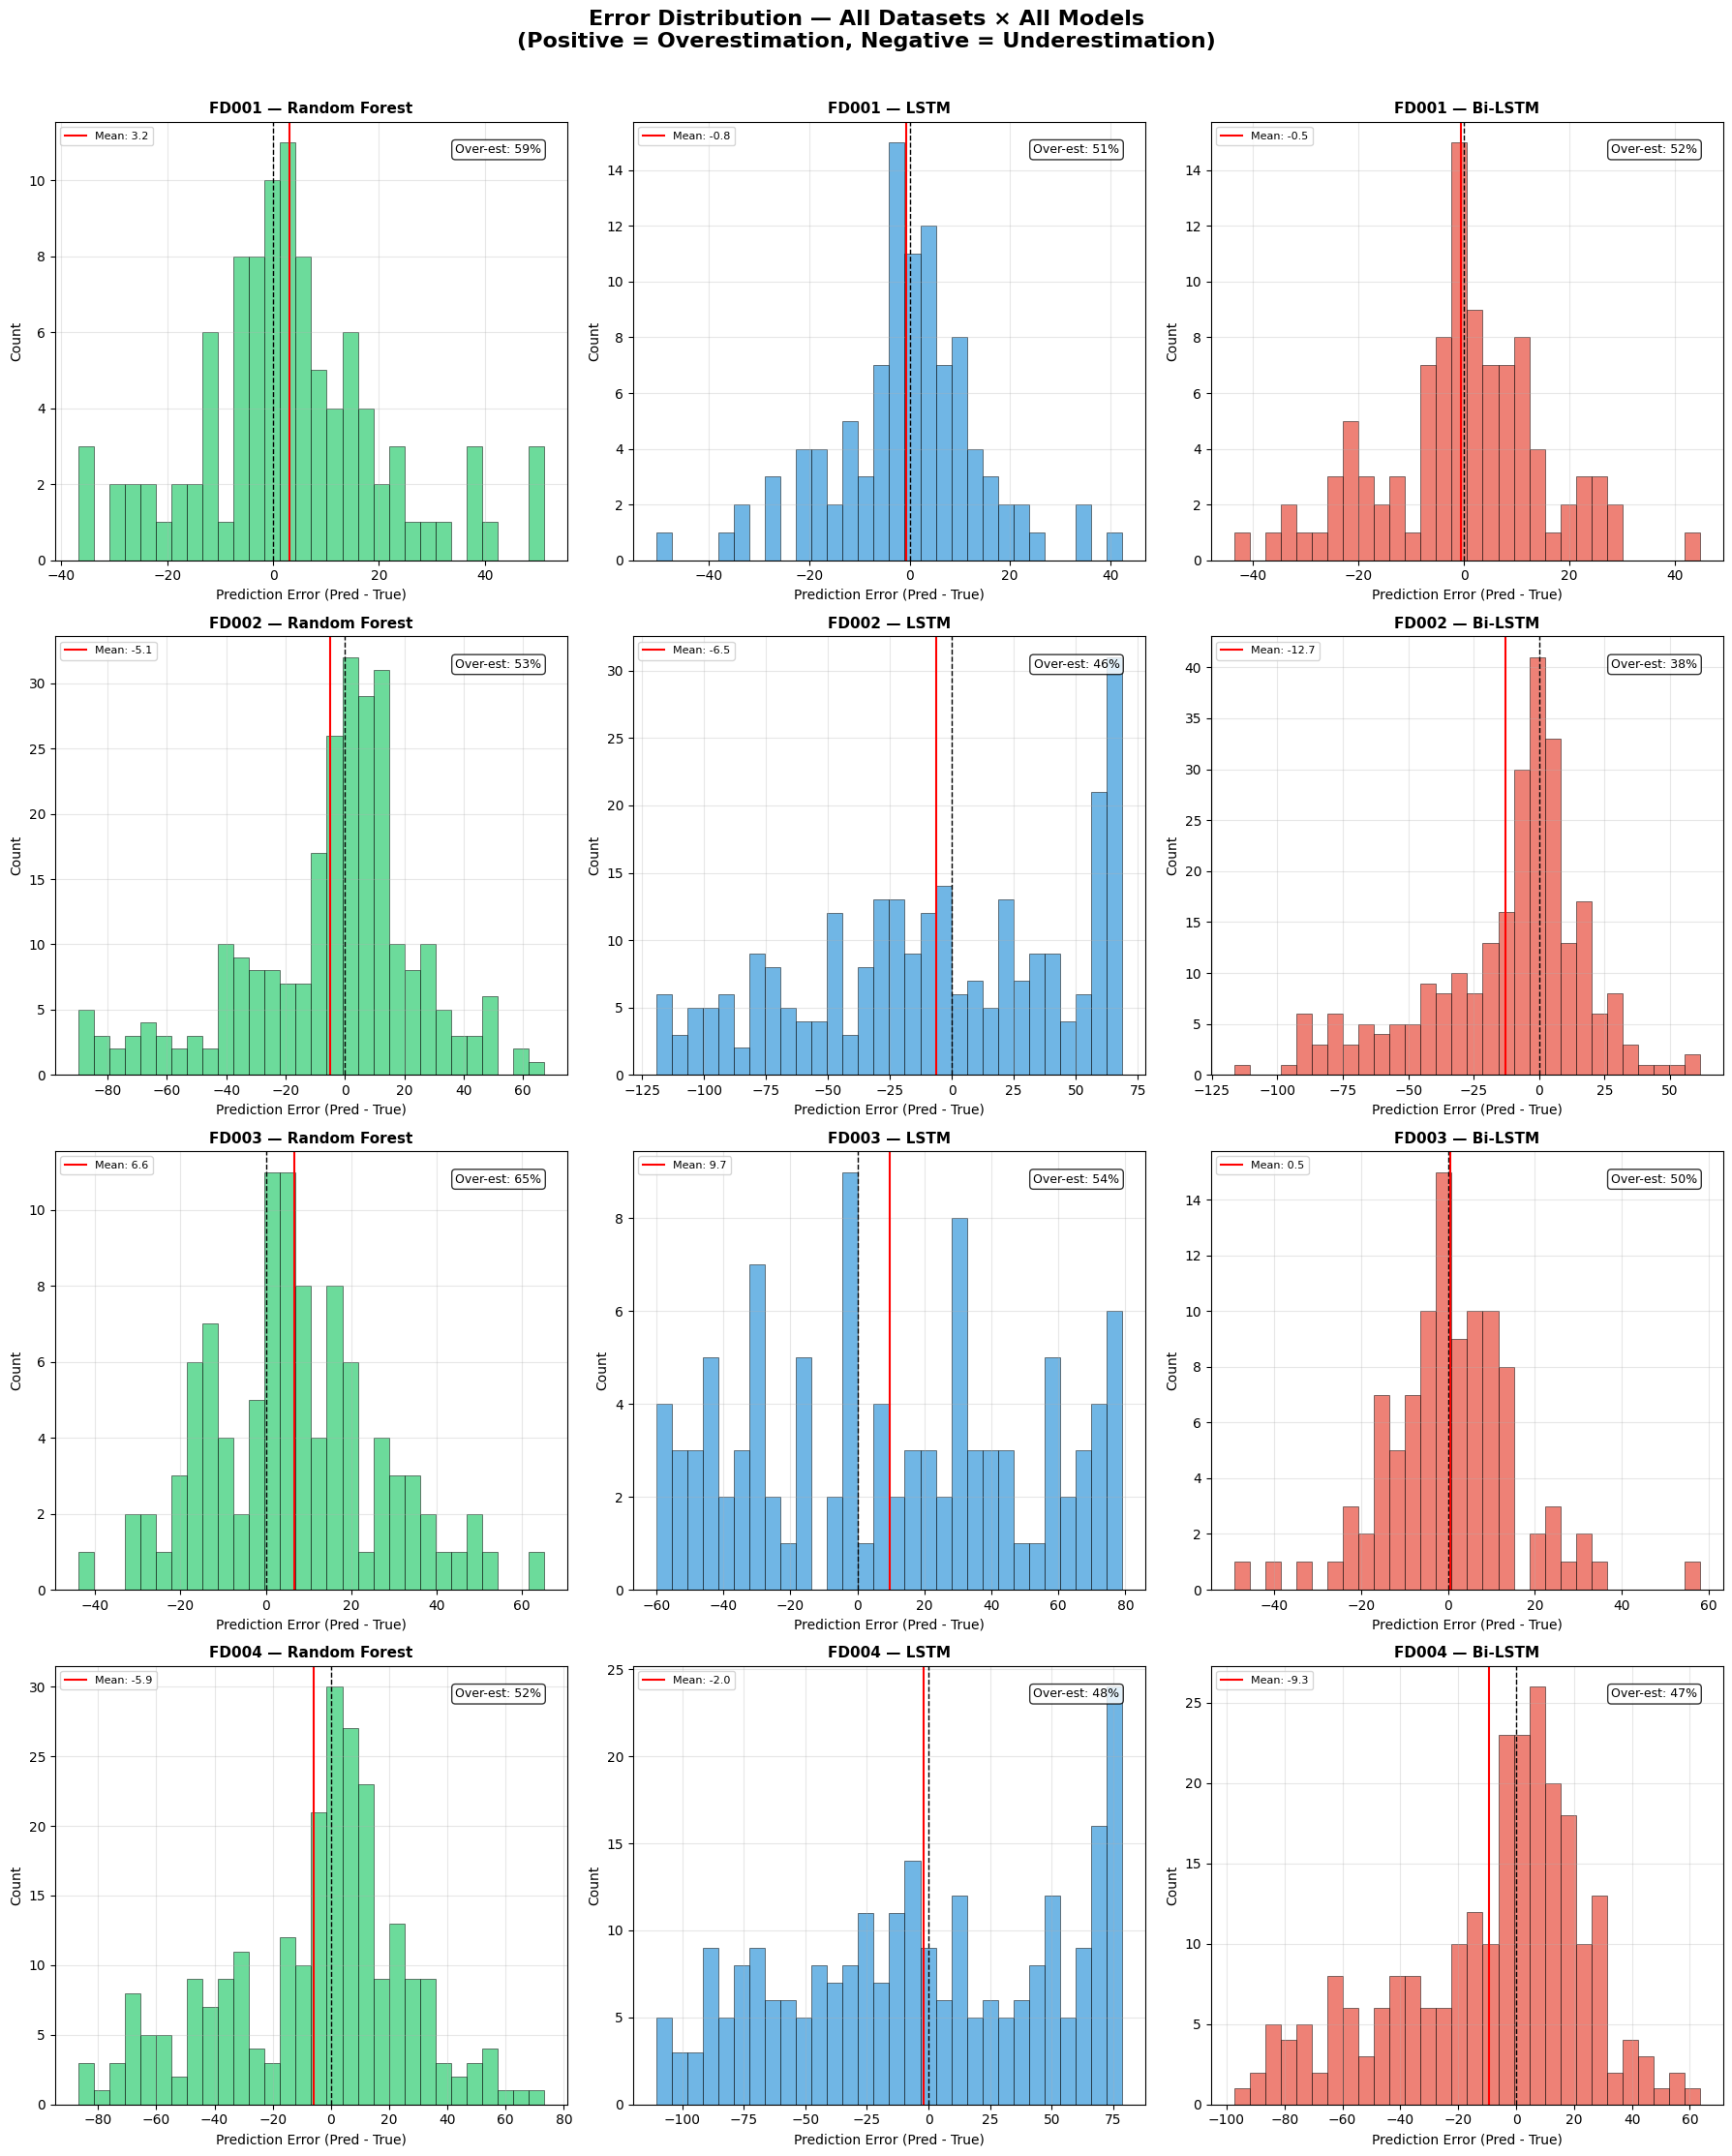

✓ Error distributions saved to /kaggle/working/results/error_distribution.png


In [18]:
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

for row, dataset_name in enumerate(DATASETS):
    for col, (model_name, color) in enumerate(zip(model_names, colors)):
        ax = axes[row, col]
        
        y_true, y_pred = all_predictions[(dataset_name, model_name)]
        errors = y_pred - y_true  # Positive = overestimation (dangerous)
        
        ax.hist(errors, bins=30, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        
        # Add mean error annotation
        mean_err = np.mean(errors)
        ax.axvline(x=mean_err, color='red', linestyle='-', linewidth=1.5, label=f'Mean: {mean_err:.1f}')
        
        over_pct = (errors > 0).sum() / len(errors) * 100
        ax.text(0.95, 0.95, f'Over-est: {over_pct:.0f}%', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_title(f'{dataset_name} — {model_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Prediction Error (Pred - True)')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Error Distribution — All Datasets × All Models\n(Positive = Overestimation, Negative = Underestimation)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "error_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Error distributions saved to {RESULTS_DIR}/error_distribution.png")

## 10. Analysis & Key Takeaways

In [19]:
# Best model per dataset
print("─── Best Model Per Dataset (by RMSE) ───\n")
for dataset in DATASETS:
    subset = results_df[results_df['Dataset'] == dataset]
    best_row = subset.loc[subset['RMSE'].idxmin()]
    print(f"  {dataset}: {best_row['Model']} (RMSE={best_row['RMSE']}, R²={best_row['R²']}, S-Score={best_row['NASA S-Score']})")

print()

# Overall best
best_overall = results_df.loc[results_df['RMSE'].idxmin()]
print(f"─── Overall Best Single Result ───")
print(f"  {best_overall['Model']} on {best_overall['Dataset']} (RMSE={best_overall['RMSE']})")

print()

# Average performance across all datasets
print("─── Average Performance Across All Datasets ───\n")
avg_perf = results_df.groupby('Model')[['RMSE', 'R²', 'NASA S-Score']].mean()
avg_perf = avg_perf.loc[['Random Forest', 'LSTM', 'Bi-LSTM']]
print(avg_perf.round(2).to_string())

─── Best Model Per Dataset (by RMSE) ───

  FD001: LSTM (RMSE=14.98, R²=0.87, S-Score=378.29)
  FD002: Random Forest (RMSE=30.48, R²=0.6788, S-Score=12660.21)
  FD003: Bi-LSTM (RMSE=15.42, R²=0.8613, S-Score=651.74)
  FD004: Random Forest (RMSE=32.08, R²=0.6539, S-Score=11595.93)

─── Overall Best Single Result ───
  LSTM on FD001 (RMSE=14.98)

─── Average Performance Across All Datasets ───

                RMSE    R²  NASA S-Score
Model                                   
Random Forest  25.47  0.72       6749.89
LSTM           41.56  0.20      70064.48
Bi-LSTM        24.64  0.74      10012.34


In [20]:
# Difficulty analysis
print("─── Dataset Difficulty Ranking (by avg RMSE across models) ───\n")
difficulty = results_df.groupby('Dataset')['RMSE'].mean().sort_values()
for rank, (ds, rmse) in enumerate(difficulty.items(), 1):
    conditions = {'FD001': '1 cond, 1 fault', 'FD002': '6 cond, 1 fault', 
                  'FD003': '1 cond, 2 faults', 'FD004': '6 cond, 2 faults'}
    print(f"  {rank}. {ds} ({conditions[ds]}) — Avg RMSE: {rmse:.2f}")

print()
print("Expected: FD001 (easiest) < FD003 < FD002 < FD004 (hardest)")
print("Multiple operating conditions (FD002/FD004) typically increase difficulty more than multiple fault modes.")

─── Dataset Difficulty Ranking (by avg RMSE across models) ───

  1. FD001 (1 cond, 1 fault) — Avg RMSE: 16.21
  2. FD003 (1 cond, 2 faults) — Avg RMSE: 26.38
  3. FD002 (6 cond, 1 fault) — Avg RMSE: 39.41
  4. FD004 (6 cond, 2 faults) — Avg RMSE: 40.21

Expected: FD001 (easiest) < FD003 < FD002 < FD004 (hardest)
Multiple operating conditions (FD002/FD004) typically increase difficulty more than multiple fault modes.


## 11. Conclusion

This multi-dataset evaluation provides evidence for:

1. **Model generalization** — How each model handles increasing dataset complexity
2. **Architecture value** — Whether the added complexity of LSTM/Bi-LSTM pays off consistently across all datasets
3. **Dataset difficulty** — Confirming that multi-condition datasets (FD002, FD004) are significantly harder than single-condition ones

The results can be directly compared with published benchmarks on the C-MAPSS dataset.